# nb06 — Prediction status: sector error, confidence ranges, live calls

Companion to **`docs/status_report_0725.md`**. Visualises the T-3 backtest (n=88 CPI prints,
2019-01→2026-06) by sector, the empirical confidence ranges, the cancellation structure, and the two
**standing (ungraded)** forward ledger calls.

Doctrine: this notebook **imports** from `src/nowcast/` and reads committed artifacts — no business
logic lives here (CLAUDE.md rule 1). Frozen configs are read, never written. The live ledger rows are
displayed as *predictions*, not results: PCE 2026-06 adjudicates **2026-07-30**, CPI 2026-07 on
**2026-08-12**.

In [1]:
import sys, json, datetime as dt
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))
import numpy as np, matplotlib.pyplot as plt
from nowcast import ledger as L, benchmarks as B

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": .3,
                     "axes.spines.top": False, "axes.spines.right": False})
REPO = Path.cwd().parent
print("ledger integrity:", L.verify() or "intact")

ledger integrity: intact


## 1. Rebuild the sector backtest

`sector_backtest()` lives in `src/nowcast/sector_report.py` so this notebook only plots.

In [2]:
from nowcast import sector_report as SR

data = SR.sector_backtest()          # T-3 freeze, per-major-group, official NSA MoM as truth
stats = SR.sector_stats(data)
for r in stats:
    print(f"{r['sector']:26} wt {r['weight_share']*100:5.1f}%  MAE {r['mae_bp']:6.1f}bp  "
          f"bias {r['bias_bp']:+6.1f}  80% [{r['p10_bp']:+6.0f},{r['p90_bp']:+6.0f}]  n={r['n']}")

Housing                    wt  43.8%  MAE   12.8bp  bias   -5.8  80% [   -32,   +11]  n=88
Transportation             wt  16.6%  MAE   45.0bp  bias   -4.0  80% [   -84,   +59]  n=88
Food & beverages           wt  15.0%  MAE   20.1bp  bias   -8.0  80% [   -45,   +19]  n=88
Medical care               wt   8.5%  MAE   22.1bp  bias   +0.0  80% [   -32,   +33]  n=88
Education & communication  wt   6.1%  MAE   20.8bp  bias   -6.8  80% [   -38,   +26]  n=88
Recreation                 wt   4.7%  MAE   30.6bp  bias   -9.7  80% [   -65,   +35]  n=88
Other goods & services     wt   2.9%  MAE   27.1bp  bias  -10.9  80% [   -52,   +30]  n=88
Apparel                    wt   2.5%  MAE   77.1bp  bias   -6.4  80% [  -116,  +113]  n=88


## 2. Sector error vs weight — where error is *expensive*

Bubble area = CPI weight. A sector far right with a big bubble is what actually costs us.

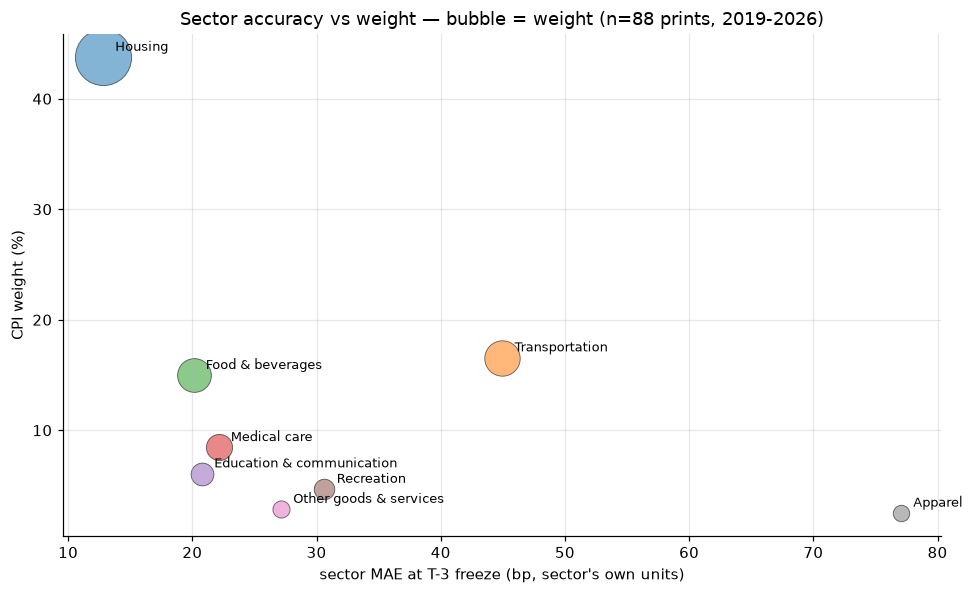

In [3]:
fig, ax = plt.subplots(figsize=(9,5.5))
for r in stats:
    ax.scatter(r["mae_bp"], r["weight_share"]*100, s=r["weight_share"]*3000+40,
               alpha=.55, edgecolor="k", linewidth=.6)
    ax.annotate(r["sector"], (r["mae_bp"], r["weight_share"]*100),
                textcoords="offset points", xytext=(8,4), fontsize=8.5)
ax.set_xlabel("sector MAE at T-3 freeze (bp, sector's own units)")
ax.set_ylabel("CPI weight (%)")
ax.set_title("Sector accuracy vs weight — bubble = weight (n=88 prints, 2019-2026)")
plt.tight_layout(); plt.show()

## 3. Confidence ranges by sector (80% empirical band)

Boxes are the 10th–90th percentile of *signed* error; the line is bias. Note the asymmetry —
several sectors skew negative (we under-predict).

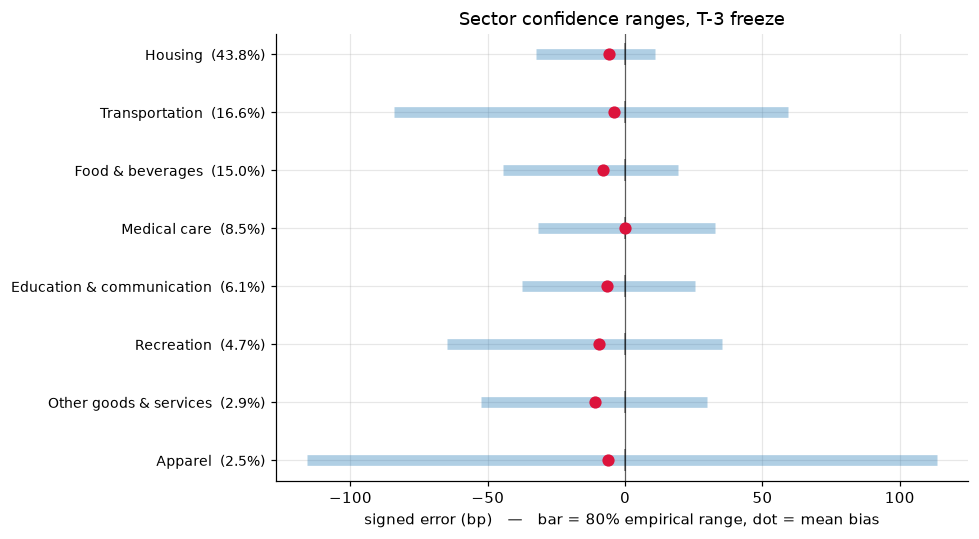

In [4]:
order = sorted(stats, key=lambda r: -r["weight_share"])
y = np.arange(len(order))
fig, ax = plt.subplots(figsize=(9,5))
for i, r in enumerate(order):
    ax.hlines(i, r["p10_bp"], r["p90_bp"], lw=7, alpha=.35)
    ax.plot(r["bias_bp"], i, "o", ms=7, color="crimson", zorder=3)
    ax.plot(0, i, "|", ms=14, color="k", alpha=.5)
ax.set_yticks(y); ax.set_yticklabels([f"{r['sector']}  ({r['weight_share']*100:.1f}%)" for r in order], fontsize=9)
ax.axvline(0, color="k", lw=.8, alpha=.6)
ax.set_xlabel("signed error (bp)   —   bar = 80% empirical range, dot = mean bias")
ax.set_title("Sector confidence ranges, T-3 freeze")
ax.invert_yaxis(); plt.tight_layout(); plt.show()

## 4. The cancellation structure

Gross sector error (Σ|weighted contribution|) vs the net aggregate miss. The aggregate is ~2×
better than its parts because sector errors partly offset — the same property the PCE bridge shows
at 4.0× (`docs/pce_wedge_decomposition.md`). **Part of the headline accuracy is offsetting, not
per-sector precision.**

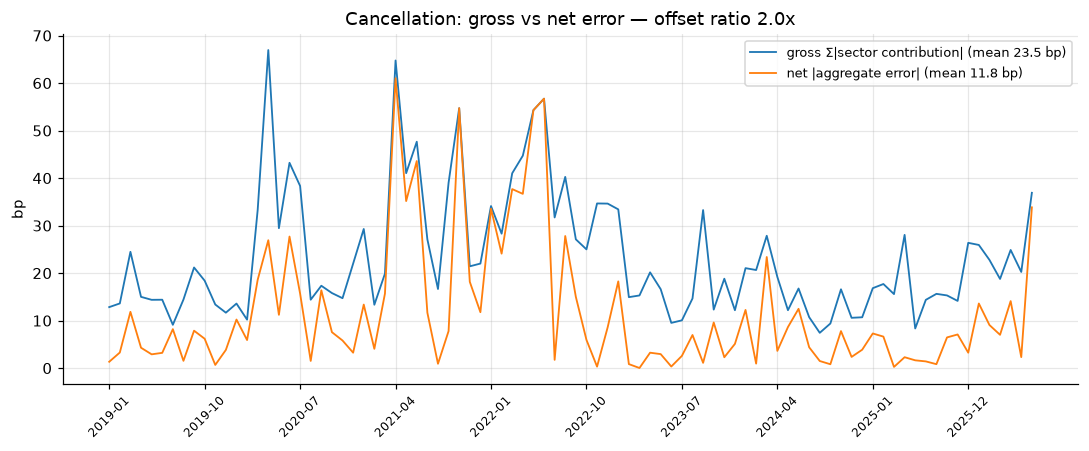

In [5]:
gross, net = SR.offset_series(data)
fig, ax = plt.subplots(figsize=(10,4.2))
ax.plot(gross["months"], gross["values"], lw=1.2, label=f"gross Σ|sector contribution| (mean {np.mean(gross['values']):.1f} bp)")
ax.plot(net["months"], np.abs(net["values"]), lw=1.2, label=f"net |aggregate error| (mean {np.mean(np.abs(net['values'])):.1f} bp)")
ax.set_xticks(gross["months"][::9]); ax.set_xticklabels([m[:7] for m in gross["months"][::9]], rotation=45, fontsize=8)
ax.set_ylabel("bp"); ax.legend(fontsize=8.5)
ax.set_title(f"Cancellation: gross vs net error — offset ratio {np.mean(gross['values'])/np.mean(np.abs(net['values'])):.1f}x")
plt.tight_layout(); plt.show()

## 5. Aggregate error distribution + the confidence range actually quoted

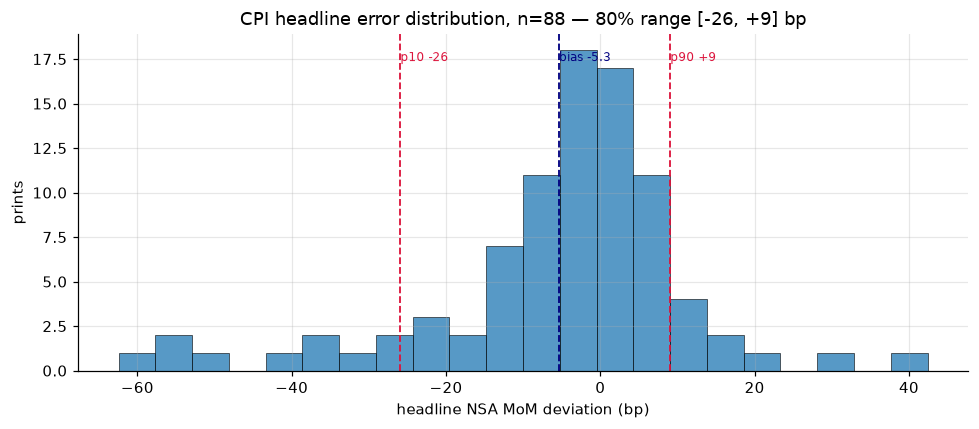

published-convention view: MAE 11.5 bp = 0.1151 pp = 1.15 of one 0.1pp increment


In [6]:
dev = SR.aggregate_devs("cpi_headline")
p10, p90 = np.percentile(dev, [10, 90])
fig, ax = plt.subplots(figsize=(9,4))
ax.hist(dev, bins=22, alpha=.75, edgecolor="k", linewidth=.5)
for v, lab, c in ((p10, f"p10 {p10:+.0f}", "crimson"), (p90, f"p90 {p90:+.0f}", "crimson"),
                  (dev.mean(), f"bias {dev.mean():+.1f}", "navy")):
    ax.axvline(v, color=c, ls="--", lw=1.2); ax.annotate(lab, (v, ax.get_ylim()[1]*.92), fontsize=8, color=c)
ax.set_xlabel("headline NSA MoM deviation (bp)"); ax.set_ylabel("prints")
ax.set_title(f"CPI headline error distribution, n={len(dev)} — 80% range [{p10:+.0f}, {p90:+.0f}] bp")
plt.tight_layout(); plt.show()
print(f"published-convention view: MAE {np.abs(dev).mean():.1f} bp = {np.abs(dev).mean()/100:.4f} pp "
      f"= {np.abs(dev).mean()/10:.2f} of one 0.1pp increment")

## 6. The live calls — STANDING, ungraded

Read straight from the append-only pristine ledger. `realized` is `—` until the print lands; this
notebook must never fill it in.

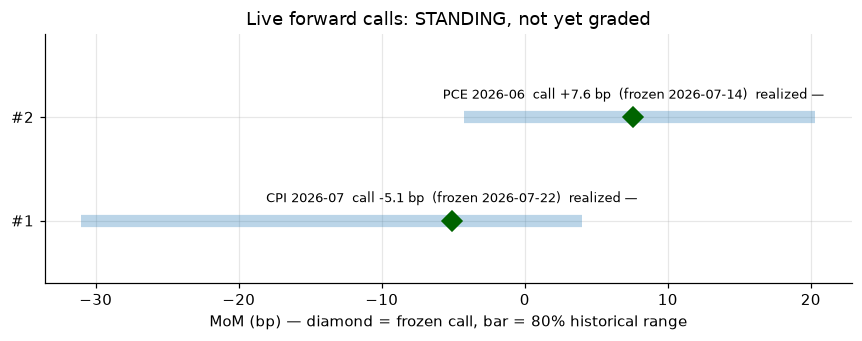

#1 cpi 2026-07: call -5.1 band ±8.8 | realized — | verdict — | hash 265f227e5cbb
#2 pce 2026-06: call +7.6 band ±8.0 | realized — | verdict — | hash ab0165470397


In [7]:
rows = L.read_rows()
band = {"cpi": np.percentile(SR.aggregate_devs("cpi_headline"), [10,90]),
        "pce": np.percentile(SR.aggregate_devs("pce_core"), [10,90])}
fig, ax = plt.subplots(figsize=(8,3.2))
for i, r in enumerate(rows):
    call = float(r["call_bp"]); lo, hi = band[r["instrument"]]
    ax.hlines(i, call+lo, call+hi, lw=8, alpha=.3)
    ax.plot(call, i, "D", ms=9, color="darkgreen", zorder=3)
    ax.annotate(f"{r['instrument'].upper()} {r['ref_month'][:7]}  call {r['call_bp']} bp  "
                f"(frozen {r['as_of']})  realized {r['realized_bp']}",
                (call, i), textcoords="offset points", xytext=(0,12), fontsize=8.5, ha="center")
ax.set_yticks(range(len(rows))); ax.set_yticklabels([f"#{r['n']}" for r in rows])
ax.set_xlabel("MoM (bp) — diamond = frozen call, bar = 80% historical range")
ax.set_title("Live forward calls: STANDING, not yet graded")
ax.set_ylim(-.6, len(rows)-.2); plt.tight_layout(); plt.show()
for r in rows:
    print(f"#{r['n']} {r['instrument']} {r['ref_month'][:7]}: call {r['call_bp']} band ±{r['band_bp']} "
          f"| realized {r['realized_bp']} | verdict {r['verdict']} | hash {r['row_hash']}")

---
### Honest reading

1. **Housing carries the system** — 43.8% of weight at only 12.8 bp MAE, because BLS's 6-panel design
   makes it structurally slow and the seasonal baseline fits it well.
2. **Transportation is where error concentrates** (largest gross contribution) — and it is *already*
   as tight as public weekly EIA data allows.
3. **Apparel is the worst sector** (77 bp) but nearly costless at 2.5% weight.
4. **~Half the headline accuracy is cancellation**, not precision. Any single-sector fix moves the
   aggregate less than it looks, possibly in the wrong direction.
5. The bands are **empirical quantiles over a multi-regime sample**; post-2023 error is ~half the
   full-sample figure, so these ranges are conservative for the current regime.